In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm

import sys  
sys.path.insert(1, '../../python_files/')
import qubits
import pulses

### Transmonin määrittely

In [2]:
E_C = 0.3*2*np.pi #Varausenergia (GHz)
E_J = 8*2*np.pi #Josephsonin energia (GHz)

qubit=qubits.Transmon(E_C,E_J,500)

In [3]:
print("Transmonin yksitoista ensimmäistä energiatasoa (GHz), kun E_0=0")
print(qubit.energies[0:11]-qubit.energies[0])

Transmonin yksitoista ensimmäistä energiatasoa (GHz), kun E_0=0
[  0.          25.48860139  48.57030326  69.5813038   82.4548144
 109.4189376  110.44497738 160.29841201 160.30648659 227.12458838
 227.12460681]


## Simulaatio

In [4]:
f_ef = qubit.energies[2]-qubit.energies[1] #ef-siirtymän taajuus

dim = 7

evolution_eigenbasis=qubits.time_evolution(qubit.H_D_eigbasis(dim))

In [5]:
def find_params(q,A,evolution,f_rabi,AC_stark,lims,scale):

    #Rajat AC-stark siirtymälle
    min_range = lims[0]
    max_range = lims[1]

    f_d = q.frequency #Ajotaajuus
    
    #Arvot eri ajotaajuuksille/AC-stark siirtymille
    pulse_times=[]
    max_e_vals=[]
    max_f_vals=[]
    AC_stark_vals=[]

    for i in range(min_range,max_range):
        delta = AC_stark + i/scale
        if A < 0.13:
            sim_vals = pulses.sim_3_part_pulses(f_d+delta,f_ef,A,evolution,dim,f_rabi,t_ramp=10,U_f=10)
        elif A < 0.16:
            sim_vals = pulses.sim_3_part_pulses(f_d+delta,f_ef,A,evolution,dim,f_rabi,t_ramp=10,U_f=5)
        else:
            sim_vals = pulses.sim_3_part_pulses(f_d+delta,f_ef,A,evolution,dim,f_rabi,t_ramp=10,U_f=1)
        AC_stark_vals.append(delta)
        max_e_vals.append(sim_vals[0])
        max_f_vals.append(sim_vals[1])
        pulse_times.append(sim_vals[2])

    plt.figure()
    plt.plot(AC_stark_vals, max_e_vals)
    plt.xlabel("delta=ω_d-ω_q (GHz)")
    plt.ylabel("Suurin e-tason todennäköisyys")
    plt.show()
    
    index=np.argmax(max_e_vals)
    AC_stark=AC_stark_vals[index]
    e_max=max_e_vals[index]
    f_max=max_f_vals[index]
    pi_pulse=pulse_times[index]
    
    return(AC_stark,pi_pulse,[e_max,f_max],max_e_vals)

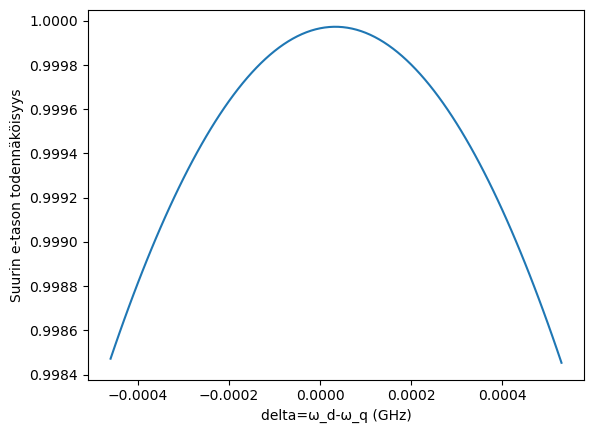

Amplitudi (GHz): 0.012744300694748212
AC-stark siirtymä (GHz): 2.987190064816114e-05
E-tason suurin todennäköisyys: 0.9999999039429638
Pulssin pituus (ns): 254.18385948643657
Rabi-taajuus (fourier):  0.0018930994403523773


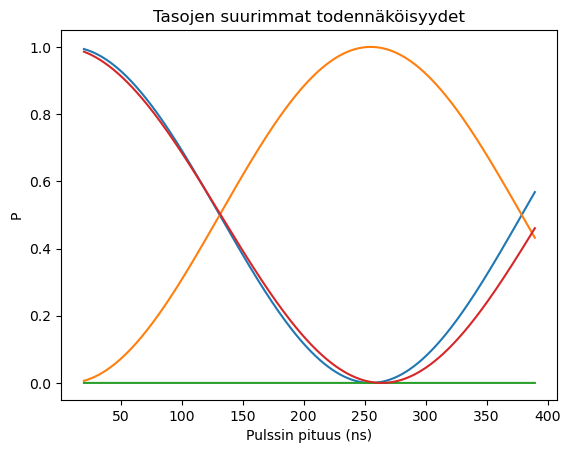

---------------------------------------------


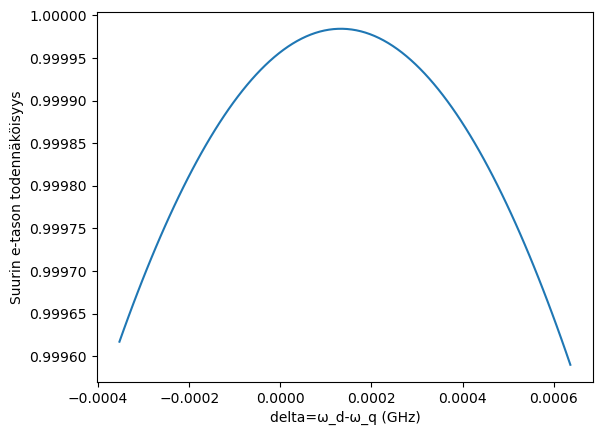

Amplitudi (GHz): 0.025488601389496424
AC-stark siirtymä (GHz): 0.00013669414394644532
E-tason suurin todennäköisyys: 0.9999999417541432
Pulssin pituus (ns): 130.92873169918
Rabi-taajuus (fourier):  0.003786214748573589


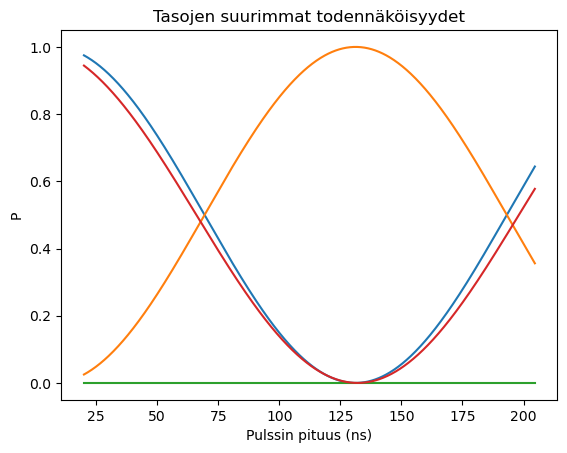

---------------------------------------------


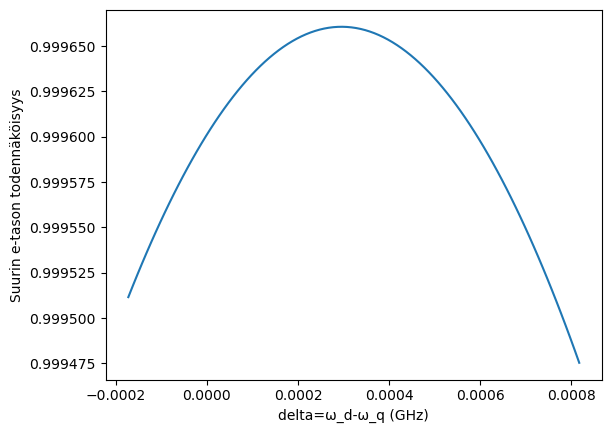

Amplitudi (GHz): 0.03823290208424464
AC-stark siirtymä (GHz): 0.0002973837298948526
E-tason suurin todennäköisyys: 0.9999998714561645
Pulssin pituus (ns): 89.021886808945
Rabi-taajuus (fourier):  0.005679357927219061


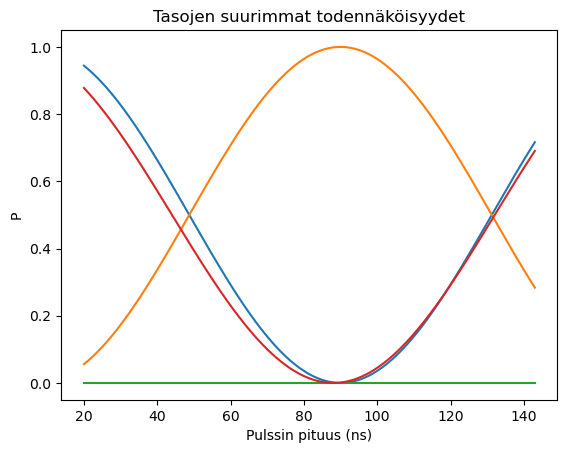

---------------------------------------------


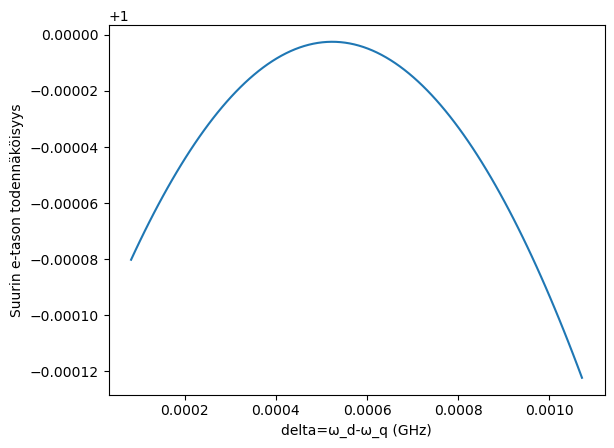

Amplitudi (GHz): 0.05097720277899285
AC-stark siirtymä (GHz): 0.0005219406584933828
E-tason suurin todennäköisyys: 0.9999999582129335
Pulssin pituus (ns): 69.30091338014958
Rabi-taajuus (fourier):  0.0075725439497365075


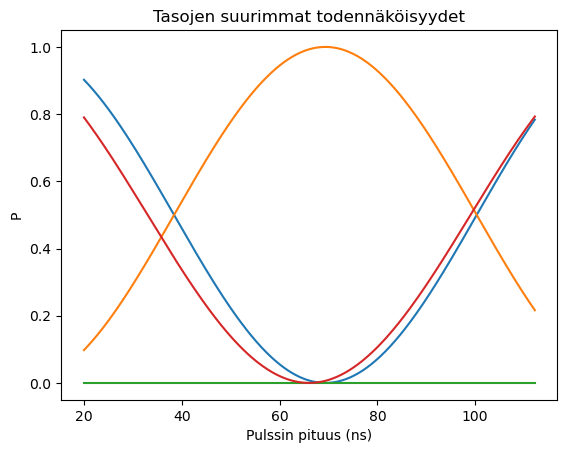

---------------------------------------------


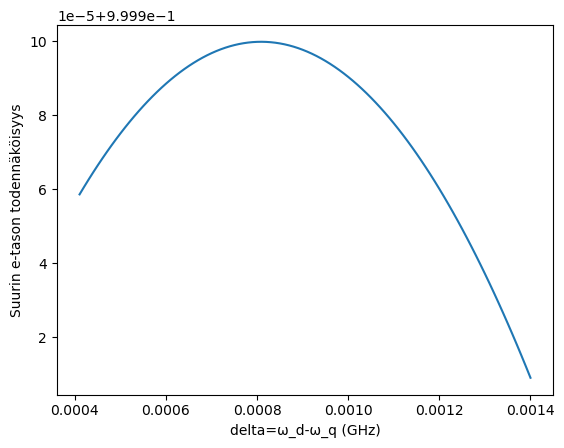

Amplitudi (GHz): 0.06372150347374106
AC-stark siirtymä (GHz): 0.0008103649297420362
E-tason suurin todennäköisyys: 0.999999975664451
Pulssin pituus (ns): 56.97526663844172
Rabi-taajuus (fourier):  0.00946578704685039


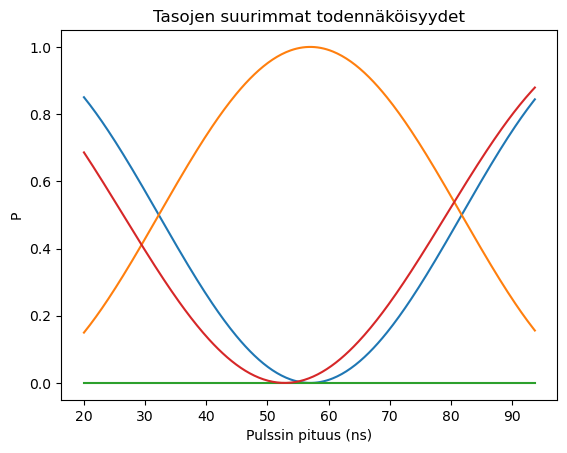

---------------------------------------------


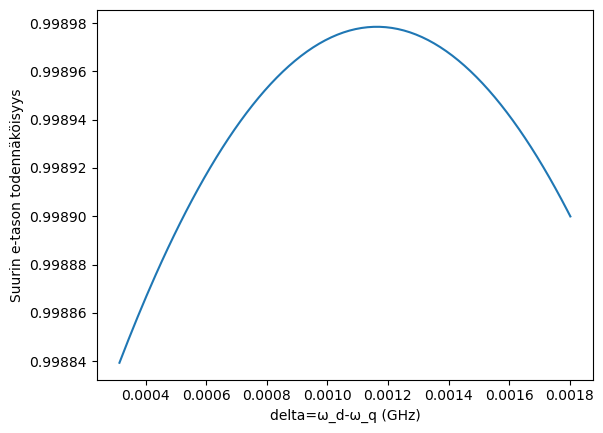

Amplitudi (GHz): 0.07646580416848928
AC-stark siirtymä (GHz): 0.001162656543640813
E-tason suurin todennäköisyys: 0.9999999083193919
Pulssin pituus (ns): 49.57980448542773
Rabi-taajuus (fourier):  0.011359101449285381


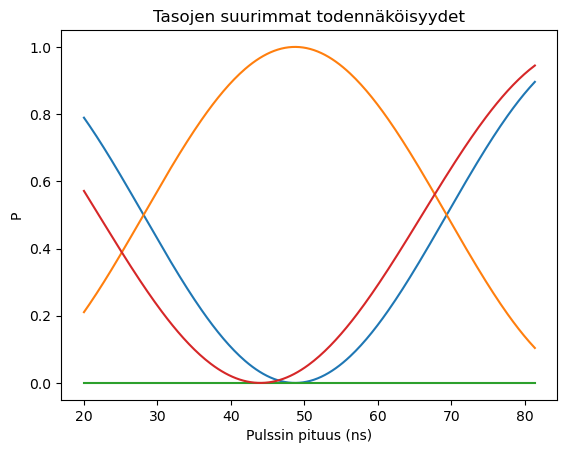

---------------------------------------------


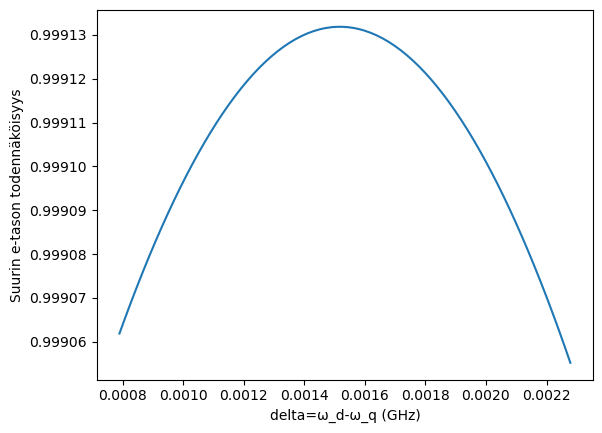

Amplitudi (GHz): 0.08921010486323748
AC-stark siirtymä (GHz): 0.001518815500189712
E-tason suurin todennäköisyys: 0.9999919037670397
Pulssin pituus (ns): 42.18454338772852
Rabi-taajuus (fourier):  0.01325777330271829


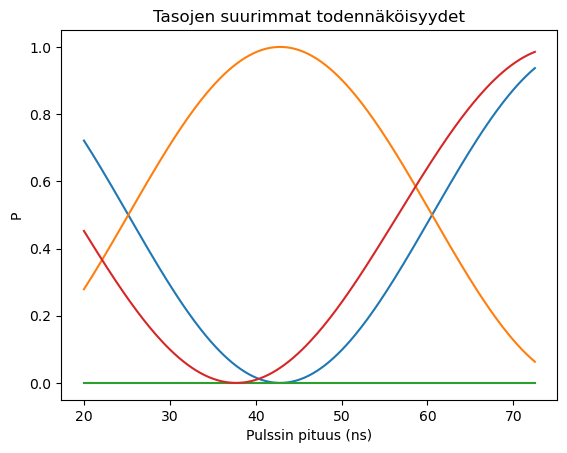

---------------------------------------------


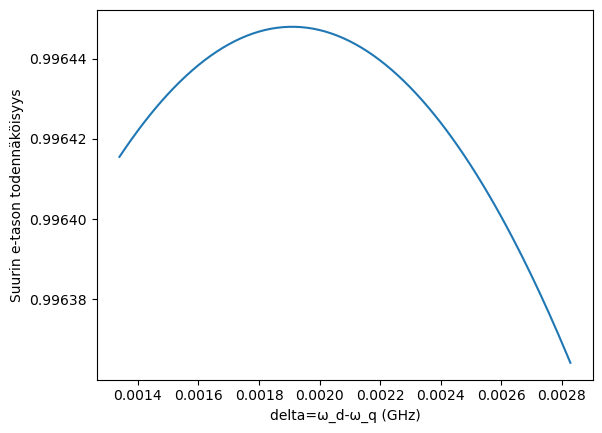

Amplitudi (GHz): 0.1019544055579857
AC-stark siirtymä (GHz): 0.0019088417993887343
E-tason suurin todennäköisyys: 0.9999987183819555
Pulssin pituus (ns): 37.25438084650739
Rabi-taajuus (fourier):  0.015145911966248897


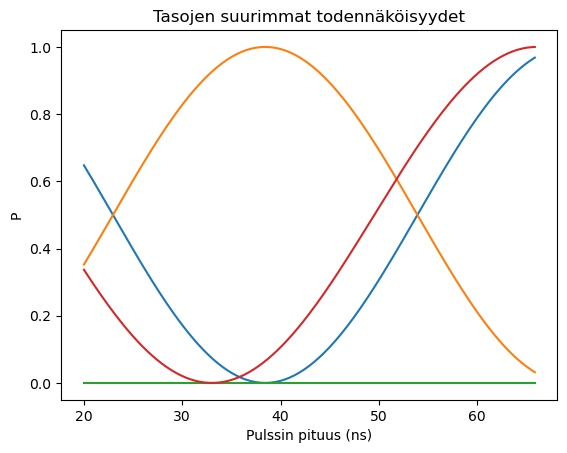

---------------------------------------------


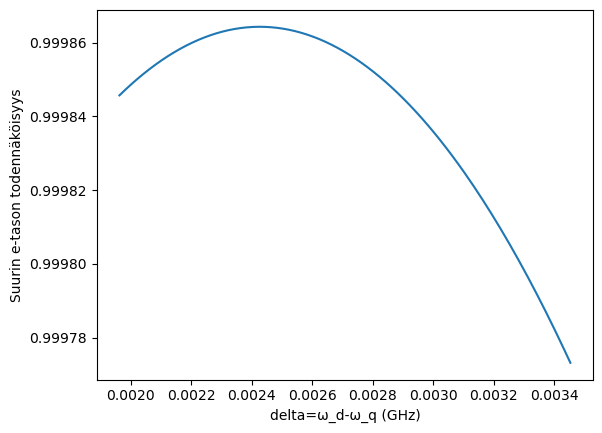

Amplitudi (GHz): 0.11469870625273391
AC-stark siirtymä (GHz): 0.00242273544123788
E-tason suurin todennäköisyys: 0.9999996807259888
Pulssin pituus (ns): 34.78917114444091
Rabi-taajuus (fourier):  0.01704631299982595


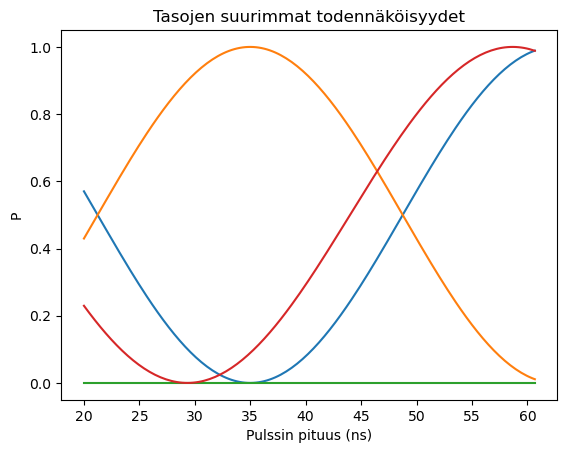

---------------------------------------------


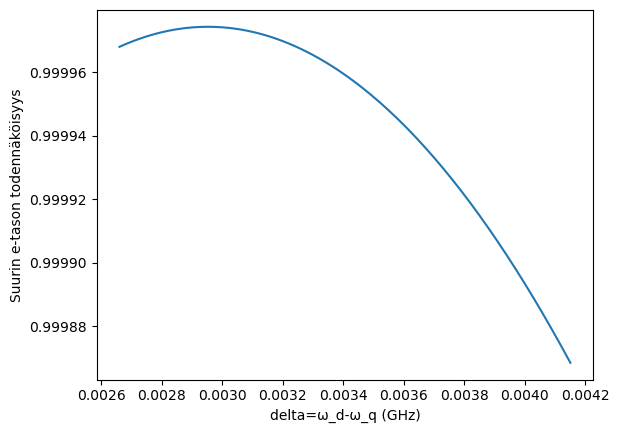

Amplitudi (GHz): 0.12744300694748215
AC-stark siirtymä (GHz): 0.0029504964257371503
E-tason suurin todennäköisyys: 0.9999743991569552
Pulssin pituus (ns): 32.3240541323212
Rabi-taajuus (fourier):  0.01893316361873098


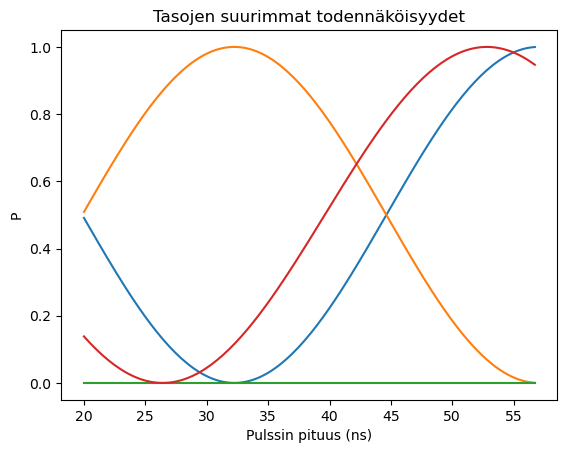

---------------------------------------------


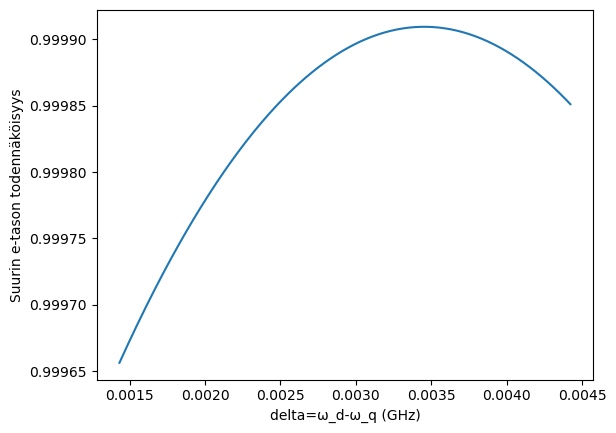

Amplitudi (GHz): 0.14018730764223034
AC-stark siirtymä (GHz): 0.0034521247528865413
E-tason suurin todennäköisyys: 0.9999997459944628
Pulssin pituus (ns): 29.859049297330984
Rabi-taajuus (fourier):  0.02083661356162243


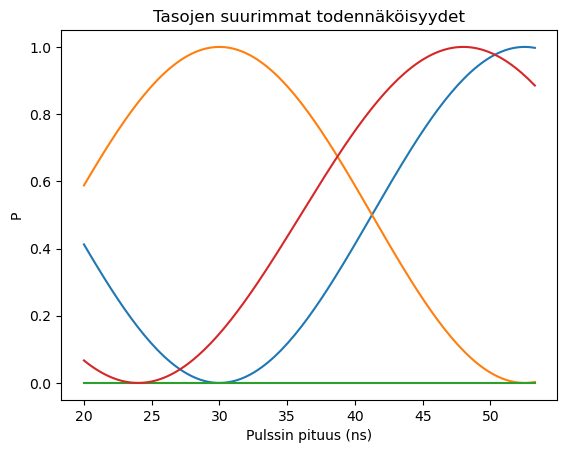

---------------------------------------------


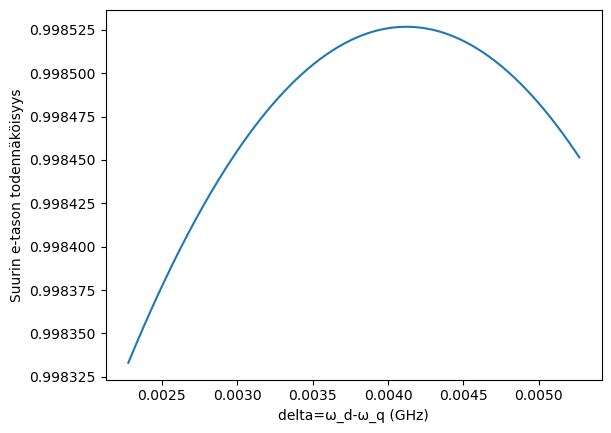

Amplitudi (GHz): 0.15293160833697855
AC-stark siirtymä (GHz): 0.004117620422686057
E-tason suurin todennäköisyys: 0.9999987067290212
Pulssin pituus (ns): 28.62644293320453
Rabi-taajuus (fourier):  0.02272083656237571


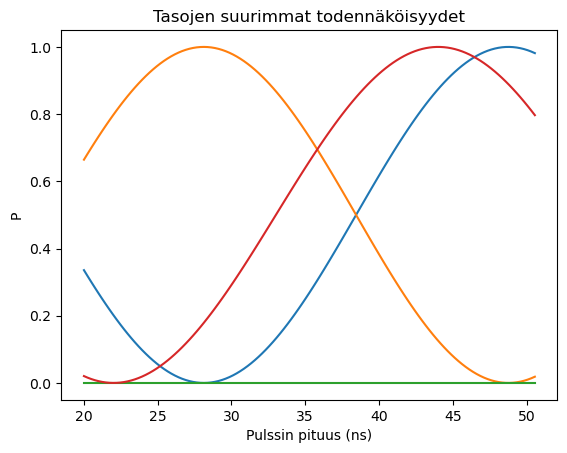

---------------------------------------------


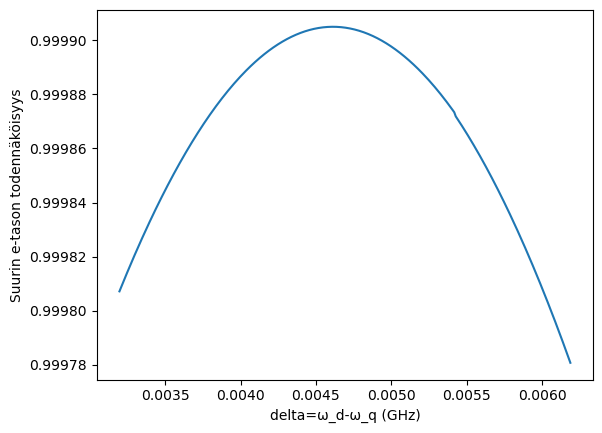

Amplitudi (GHz): 0.16567590903172677
AC-stark siirtymä (GHz): 0.004616983435135695
E-tason suurin todennäköisyys: 0.9999988278711331
Pulssin pituus (ns): 26.654554196027963
Rabi-taajuus (fourier):  0.024611440238832143


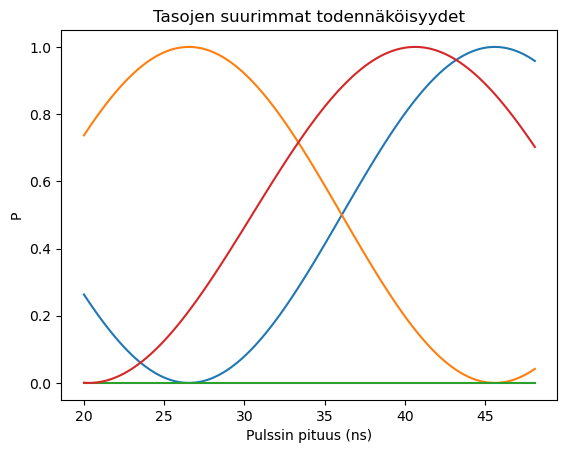

---------------------------------------------


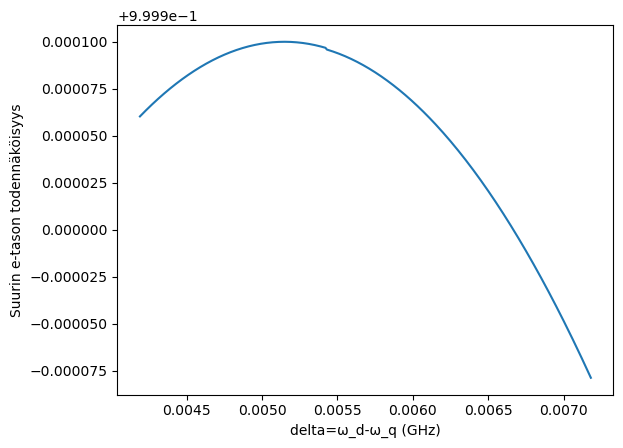

Amplitudi (GHz): 0.178420209726475
AC-stark siirtymä (GHz): 0.005150213790235456
E-tason suurin todennäköisyys: 0.9999999516726129
Pulssin pituus (ns): 25.17565611778224
Rabi-taajuus (fourier):  0.026519324089019438


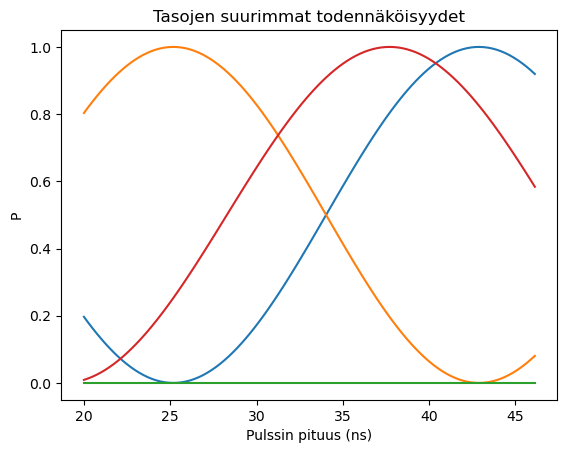

---------------------------------------------


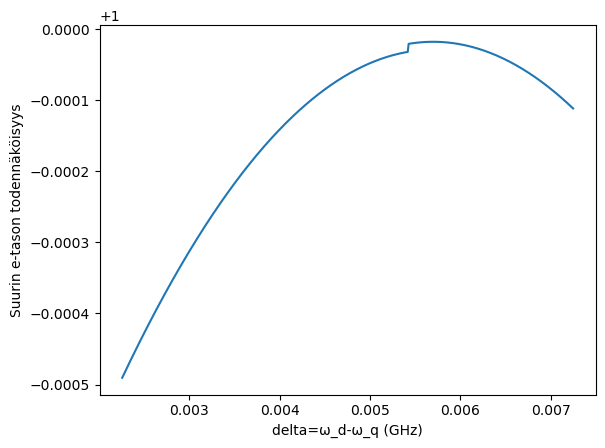

Amplitudi (GHz): 0.19116451042122318
AC-stark siirtymä (GHz): 0.005697311487985338
E-tason suurin todennäköisyys: 0.9999998224190415
Pulssin pituus (ns): 23.94327241921707
Rabi-taajuus (fourier):  0.0284028056124607


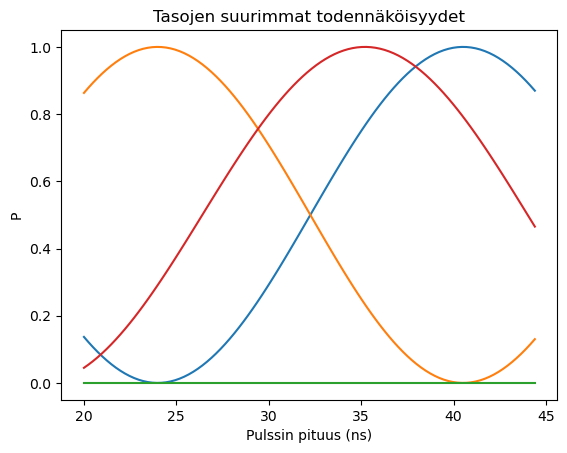

---------------------------------------------


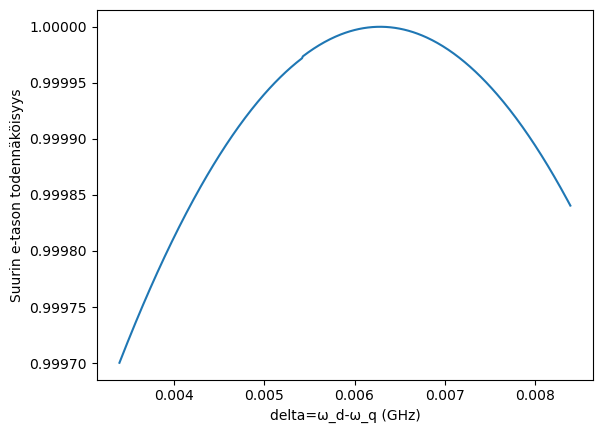

Amplitudi (GHz): 0.2039088111159714
AC-stark siirtymä (GHz): 0.006288276528385345
E-tason suurin todennäköisyys: 0.9999999327097169
Pulssin pituus (ns): 22.957385761376045
Rabi-taajuus (fourier):  0.030313195301507112


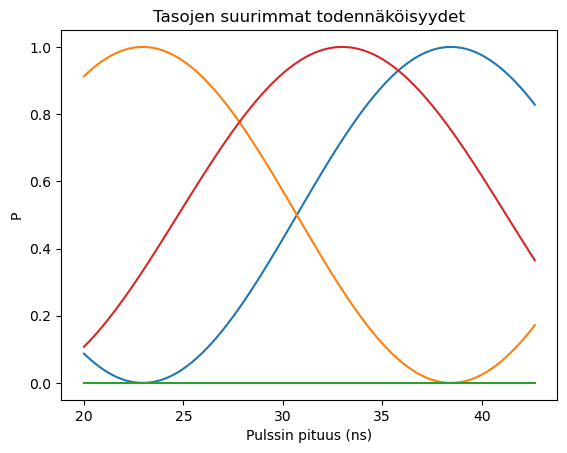

---------------------------------------------


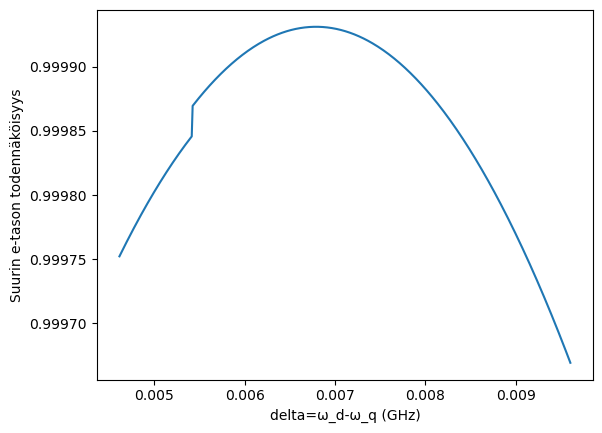

Amplitudi (GHz): 0.2166531118107196
AC-stark siirtymä (GHz): 0.006793108911435475
E-tason suurin todennäköisyys: 0.9999989003018498
Pulssin pituus (ns): 21.97155146826913
Rabi-taajuus (fourier):  0.032204111591266106


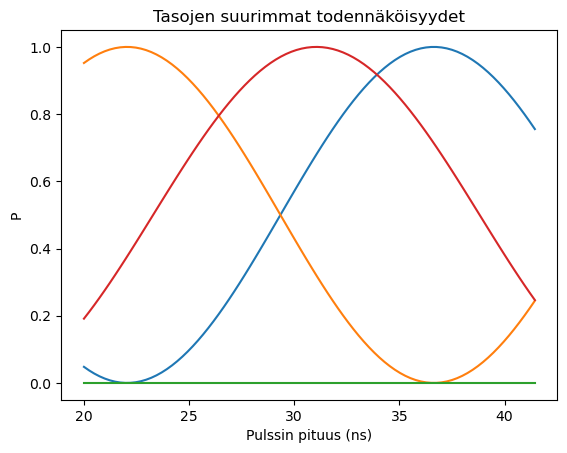

---------------------------------------------


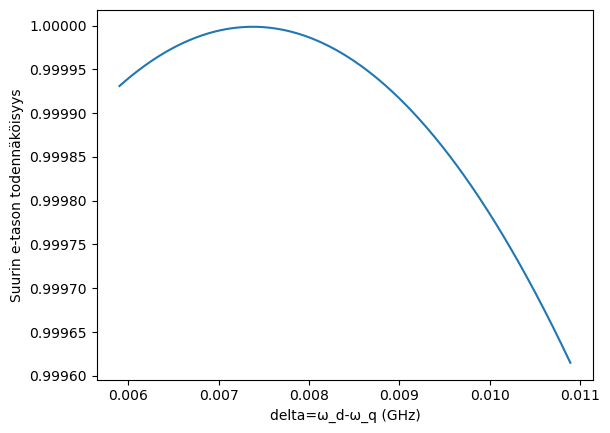

Amplitudi (GHz): 0.22939741250546783
AC-stark siirtymä (GHz): 0.00738180863713573
E-tason suurin todennäköisyys: 0.9999986087005927
Pulssin pituus (ns): 21.232191215838178
Rabi-taajuus (fourier):  0.03409925844513342


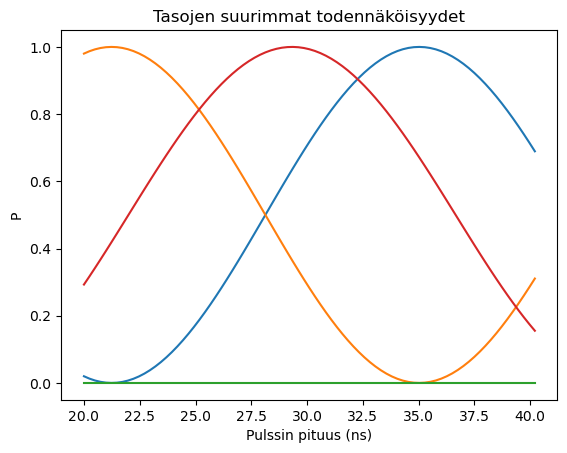

---------------------------------------------


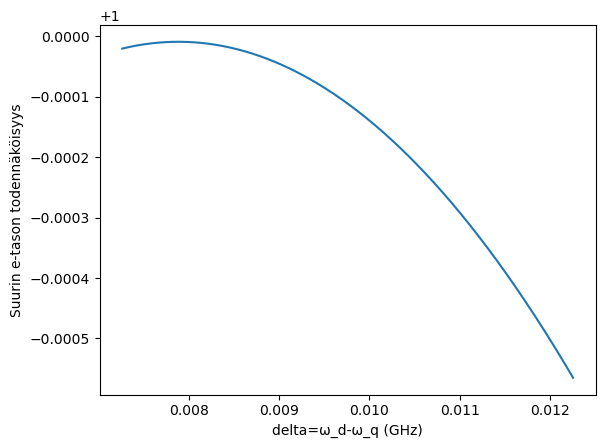

Amplitudi (GHz): 0.24214171320021607
AC-stark siirtymä (GHz): 0.00788437570548611
E-tason suurin todennäköisyys: 0.999999773110926
Pulssin pituus (ns): 20.492866771134004
Rabi-taajuus (fourier):  0.03600157438153135


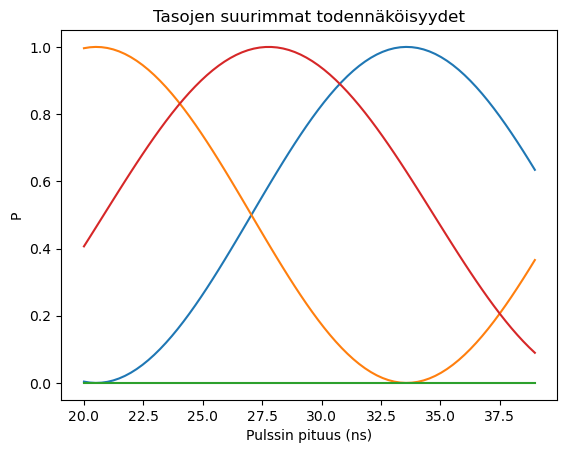

---------------------------------------------


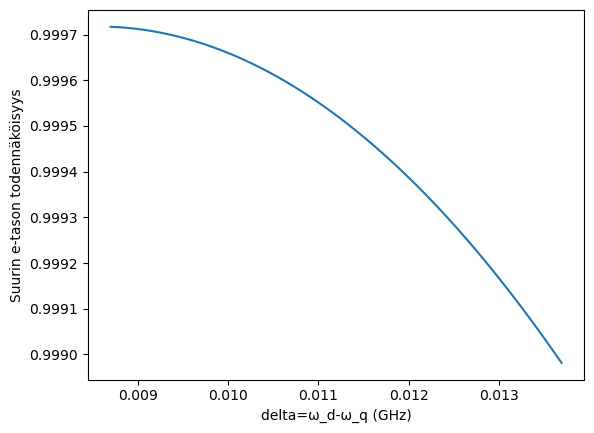

Amplitudi (GHz): 0.25488601389496424
AC-stark siirtymä (GHz): 0.008700810116486605
E-tason suurin todennäköisyys: 0.9999971875593757
Pulssin pituus (ns): 20.0
Rabi-taajuus (fourier):  0.0378748690187118


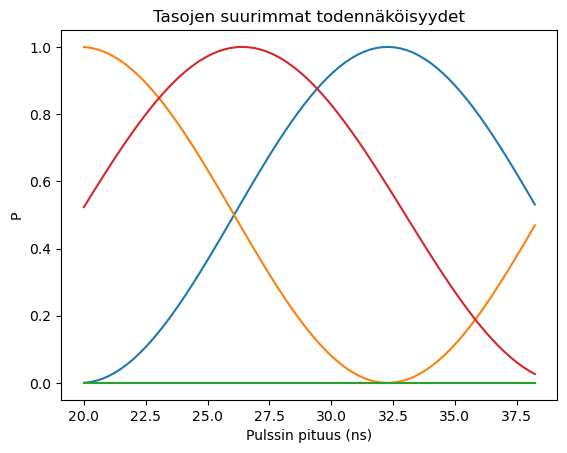

---------------------------------------------


In [6]:
deltas = [] #AC Stark siirtymät
pulse_lengths = [] #Pulssin pituudet
max_vals = [] #Suurimmat tasojen todennäköisyydet
rabis = [] #Rabi taajuudet (fouriermuunnoksesta)
data = [] #e-tason suurimmat todennäköisyydet amplitudin ja AC-stark siirtymän suhteen
A_vals = [] #Ajavan amplitudin arvot

#Määritellään rajat amplitudille sekä simulaatioiden määrä
min_range = 0.0005
max_range = 0.0100
N_data=20
d_data=(max_range-min_range)/(N_data-1)

for i in range (0,N_data):
    
    A = qubit.frequency*(min_range+i*d_data)
    A_vals.append(A)

    f_rabi = 4*A/3

    AC_stark=0.2274*A**2- 0.0003122*A + 6.917e-06 #Arvaus AC-stark siirtymälle
    if i < 5:
        params=find_params(qubit, A, evolution_eigenbasis,f_rabi,AC_stark,[-50,50],100000)
    elif i < 10:
        params=find_params(qubit, A, evolution_eigenbasis,f_rabi,AC_stark,[-100,50],100000)
    elif i < 14:
        params=find_params(qubit, A, evolution_eigenbasis,f_rabi,AC_stark,[-300,0],100000)
    else:
        params=find_params(qubit, A, evolution_eigenbasis,f_rabi,AC_stark,[-600,-100],100000)

    deltas.append(params[0])
    pulse_lengths.append(params[1])
    data.append(params[3])
    
    f_d_opt = qubit.frequency+deltas[-1] #Löydetty optimaalinen ajotaajuus

    m=10
    vals = pulses.sim_3_part_pulses(f_d_opt,f_ef,A,evolution_eigenbasis,dim,f_rabi/m,t_ramp=10,U_f=1)

    print("Amplitudi (GHz):", A)
    print("AC-stark siirtymä (GHz):", deltas[-1])

    print("E-tason suurin todennäköisyys:", vals[0])
    print("Pulssin pituus (ns):", pulse_lengths[-1])

    max_vals.append([vals[0],vals[1]])

    g_vals=np.array([arr[0] for arr in vals[3]])
    e_vals=np.array([arr[1] for arr in vals[3]])
    f_vals=np.array([arr[2] for arr in vals[3]])
    
    g_vals_offset = g_vals-0.5 #Siirretään g-tason todennäköisyyksiä puolella alaspäin, dc-komponentin minimoinniksi
    fft_vals = np.fft.rfft(g_vals_offset) #Fourier-muunnos

    #Taajuusavaruus
    freqs = np.fft.rfftfreq(len(g_vals), d=vals[4][1]-vals[4][0]) 

    magnitude = np.abs(fft_vals) #Taajuuskomponentit
    magnitude[0] = 0 #Hylätään nollataajuus/vakiokomponentti

    frequency=freqs[np.argmax(magnitude)] #Suurin g-tason aikakehityksen taajuuskomponentti=Rabi-taajuus
    print("Rabi-taajuus (fourier): ",frequency)
    rabis.append(frequency)

    n_picked = int(len(vals[3])/m) #Plottausta varten käytetty pisteiden määrä
    
    plot_vals= 0.5*(1+np.cos(2*np.pi*frequency*vals[4][:n_picked])) #Sovite Rabi-taajuudella

    plt.figure()
    plt.plot(vals[4][:n_picked], g_vals[:n_picked])
    plt.plot(vals[4][:n_picked], e_vals[:n_picked])
    plt.plot(vals[4][:n_picked], f_vals[:n_picked])
    plt.plot(vals[4][:n_picked], plot_vals)
    plt.xlabel("Pulssin pituus (ns)")
    plt.ylabel("P")
    plt.title("Tasojen suurimmat todennäköisyydet")
    plt.show()

    print("---------------------------------------------")

[np.float64(0.012744300694748212), np.float64(0.025488601389496424), np.float64(0.03823290208424464), np.float64(0.05097720277899285), np.float64(0.06372150347374106), np.float64(0.07646580416848928), np.float64(0.08921010486323748), np.float64(0.1019544055579857), np.float64(0.11469870625273391), np.float64(0.12744300694748215), np.float64(0.14018730764223034), np.float64(0.15293160833697855), np.float64(0.16567590903172677), np.float64(0.178420209726475), np.float64(0.19116451042122318), np.float64(0.2039088111159714), np.float64(0.2166531118107196), np.float64(0.22939741250546783), np.float64(0.24214171320021607), np.float64(0.25488601389496424)]


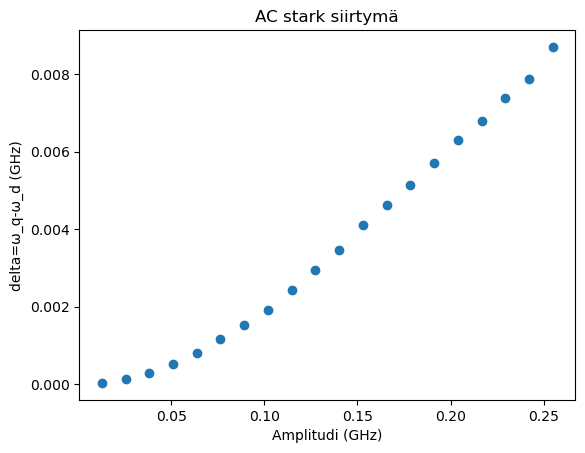

[np.float64(2.987190064816114e-05), np.float64(0.00013669414394644532), np.float64(0.0002973837298948526), np.float64(0.0005219406584933828), np.float64(0.0008103649297420362), np.float64(0.001162656543640813), np.float64(0.001518815500189712), np.float64(0.0019088417993887343), np.float64(0.00242273544123788), np.float64(0.0029504964257371503), np.float64(0.0034521247528865413), np.float64(0.004117620422686057), np.float64(0.004616983435135695), np.float64(0.005150213790235456), np.float64(0.005697311487985338), np.float64(0.006288276528385345), np.float64(0.006793108911435475), np.float64(0.00738180863713573), np.float64(0.00788437570548611), np.float64(0.008700810116486605)]


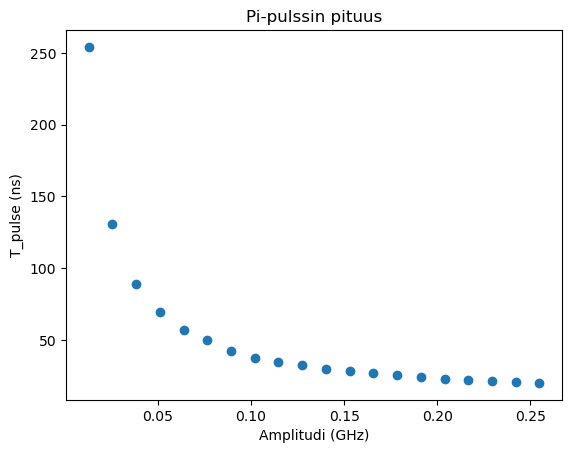

[np.float64(254.18385948643657), np.float64(130.92873169918), np.float64(89.021886808945), np.float64(69.30091338014958), np.float64(56.97526663844172), np.float64(49.57980448542773), np.float64(42.18454338772852), np.float64(37.25438084650739), np.float64(34.78917114444091), np.float64(32.3240541323212), np.float64(29.859049297330984), np.float64(28.62644293320453), np.float64(26.654554196027963), np.float64(25.17565611778224), np.float64(23.94327241921707), np.float64(22.957385761376045), np.float64(21.97155146826913), np.float64(21.232191215838178), np.float64(20.492866771134004), np.float64(20.0)]


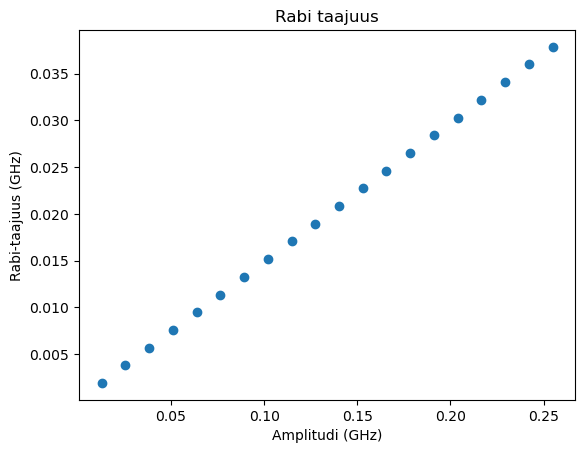

[np.float64(0.0018930994403523773), np.float64(0.003786214748573589), np.float64(0.005679357927219061), np.float64(0.0075725439497365075), np.float64(0.00946578704685039), np.float64(0.011359101449285381), np.float64(0.01325777330271829), np.float64(0.015145911966248897), np.float64(0.01704631299982595), np.float64(0.01893316361873098), np.float64(0.02083661356162243), np.float64(0.02272083656237571), np.float64(0.024611440238832143), np.float64(0.026519324089019438), np.float64(0.0284028056124607), np.float64(0.030313195301507112), np.float64(0.032204111591266106), np.float64(0.03409925844513342), np.float64(0.03600157438153135), np.float64(0.0378748690187118)]


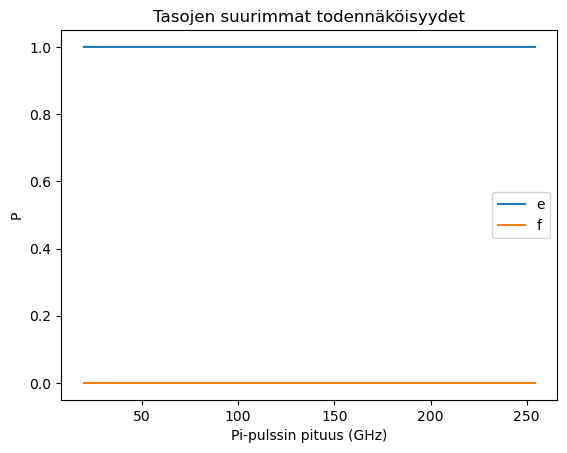

[np.float64(0.9999999039429638), np.float64(0.9999999417541432), np.float64(0.9999998714561645), np.float64(0.9999999582129335), np.float64(0.999999975664451), np.float64(0.9999999083193919), np.float64(0.9999919037670397), np.float64(0.9999987183819555), np.float64(0.9999996807259888), np.float64(0.9999743991569552), np.float64(0.9999997459944628), np.float64(0.9999987067290212), np.float64(0.9999988278711331), np.float64(0.9999999516726129), np.float64(0.9999998224190415), np.float64(0.9999999327097169), np.float64(0.9999989003018498), np.float64(0.9999986087005927), np.float64(0.999999773110926), np.float64(0.9999971875593757)]
[np.float64(8.010867898618562e-10), np.float64(3.4541690992935067e-09), np.float64(8.3630802172253e-09), np.float64(1.5959490082196072e-08), np.float64(2.6686414163423226e-08), np.float64(4.0816670192574735e-08), np.float64(5.8725525448239244e-08), np.float64(8.094232124131202e-08), np.float64(1.0865882622544303e-07), np.float64(1.4164051420303255e-07), np.fl

In [7]:
print(A_vals)

plt.figure()
plt.plot(A_vals, deltas, 'o')
plt.xlabel("Amplitudi (GHz)")
plt.ylabel("delta=ω_q-ω_d (GHz)")
plt.title("AC stark siirtymä")
plt.show()
print(deltas)

plt.figure()
plt.plot(A_vals, pulse_lengths, 'o')
plt.xlabel("Amplitudi (GHz)")
plt.ylabel("T_pulse (ns)")
plt.title("Pi-pulssin pituus")
plt.show()
print(pulse_lengths)

plt.figure()
plt.plot(A_vals, rabis, 'o')
plt.xlabel("Amplitudi (GHz)")
plt.ylabel("Rabi-taajuus (GHz)")
plt.title("Rabi taajuus")
plt.show()
print(rabis)

e_vals=[arr[0] for arr in max_vals]
f_vals=[arr[1] for arr in max_vals]

plt.figure()
plt.plot(pulse_lengths, e_vals)
plt.plot(pulse_lengths, f_vals)
plt.legend(["e","f"])
plt.xlabel("Pi-pulssin pituus (GHz)")
plt.ylabel("P")
plt.title("Tasojen suurimmat todennäköisyydet")
plt.show()
print(e_vals)
print(f_vals)

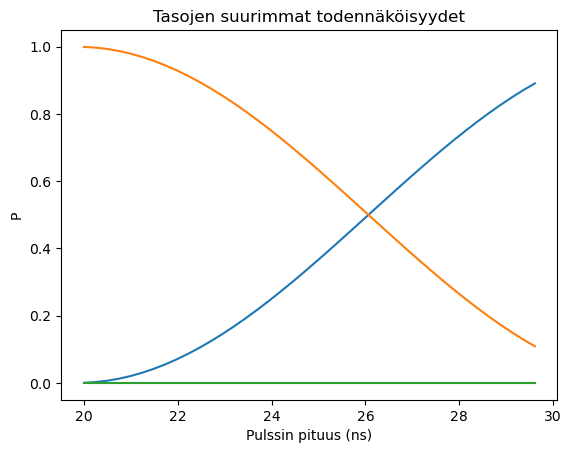

In [8]:
f_rabi=0.1
A=qubit.frequency*0.01
m=1
vals = pulses.sim_3_part_pulses(qubit.frequency+0.006190213790242355,f_ef,A,evolution_eigenbasis,dim,(f_rabi*2*np.pi)/m,t_ramp=10,U_f=1,K=20)

g_vals=np.array([arr[0] for arr in vals[3]])
e_vals=np.array([arr[1] for arr in vals[3]])
f_vals=np.array([arr[2] for arr in vals[3]])

n_picked = int(len(vals[3])/m) #Plottausta varten käytetty pisteiden määrä

plt.figure()
plt.plot(vals[4][:n_picked], g_vals[:n_picked])
plt.plot(vals[4][:n_picked], e_vals[:n_picked])
plt.plot(vals[4][:n_picked], f_vals[:n_picked])
plt.xlabel("Pulssin pituus (ns)")
plt.ylabel("P")
plt.title("Tasojen suurimmat todennäköisyydet")
plt.show()